In [8]:
import numpy as np
import cv2
from matplotlib import pyplot as plt
import os

Error loading image: Thumbs.db
Error loading image: _annotations.csv


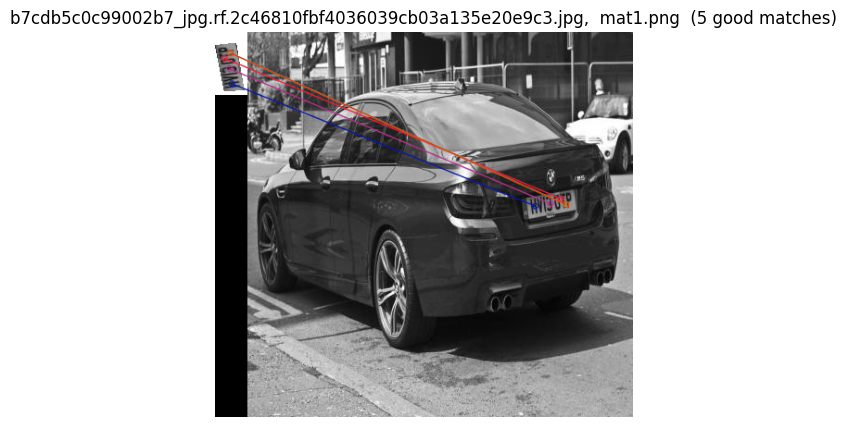

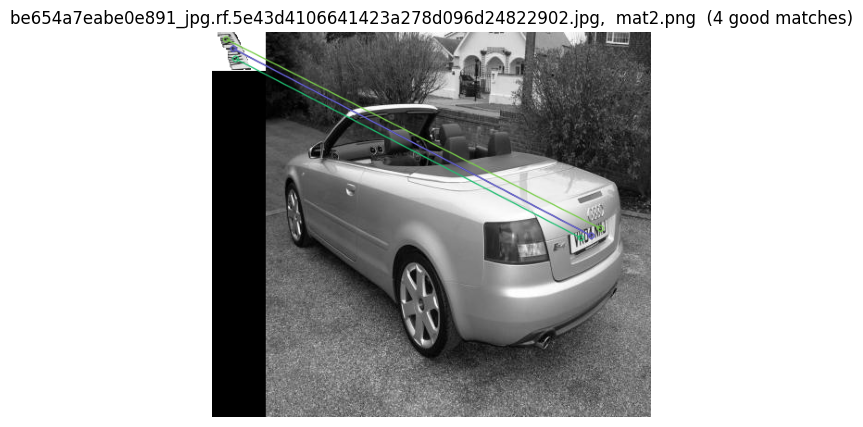

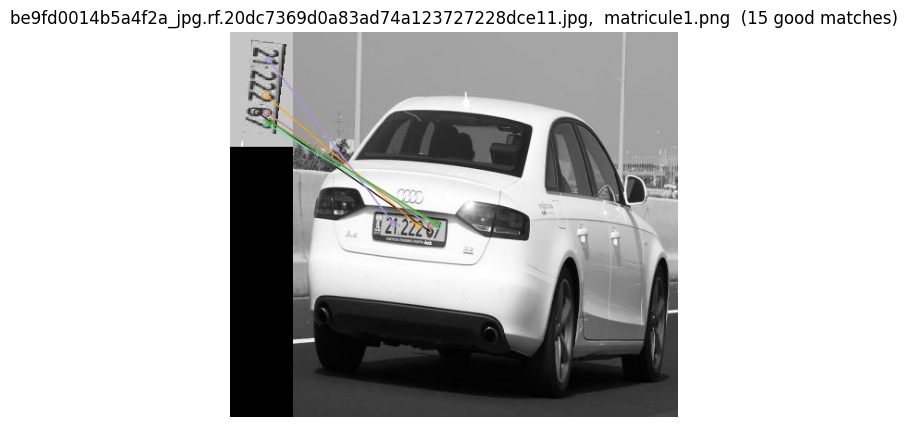

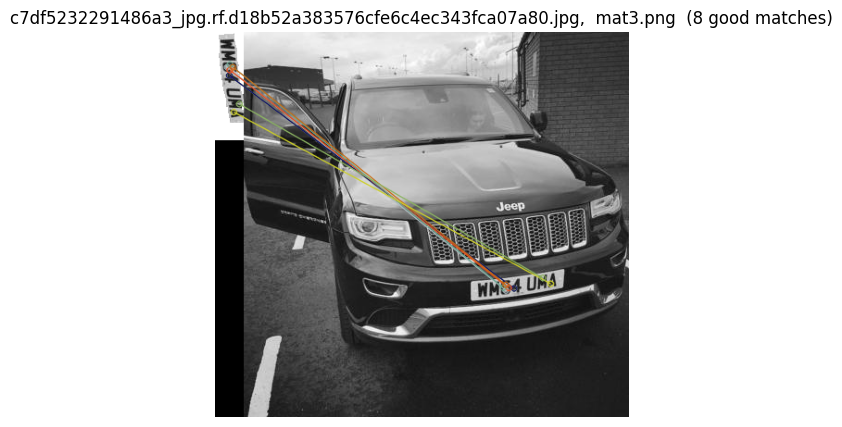

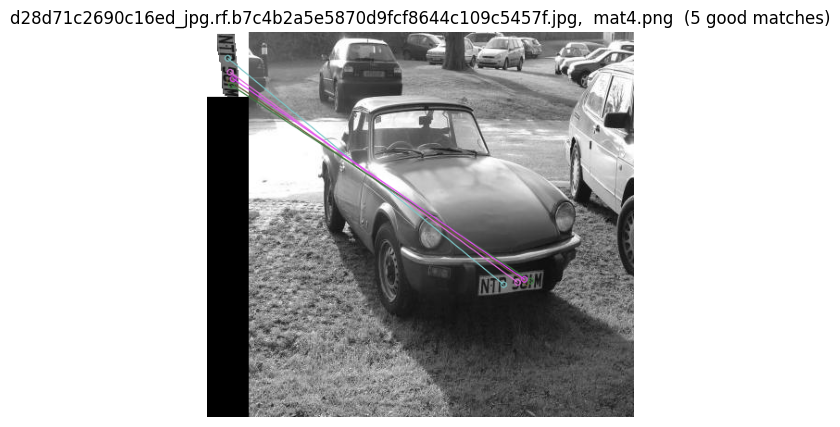

In [ ]:
sift = cv2.SIFT_create()
bf = cv2.BFMatcher()

train_dir = sorted([f for f in os.listdir('Train')])

test_dir = sorted([f for f in os.listdir('License Plates')])

for car in test_dir:
    img2=cv2.imread('License Plates/'+car,0)
    if img2 is None:
        print(f"Error loading image: {car}")
        continue
    kp2, des2 = sift.detectAndCompute(img2,None)
    if des2 is None:
        print(f"No descriptors found in image: {car}")
        continue

    for matricule in train_dir:
        img1=cv2.imread('Train/'+matricule,0)
        if img1 is None:
            print(f"Error loading image: {matricule}")
            continue
        kp1, des1 = sift.detectAndCompute(img1,None)
        if des1 is None:
            print(f"No descriptors found in image: {matricule}")
            continue


        matches = bf.knnMatch(des1,des2, k=2)


        good = [m for m, n in matches if m.distance < 0.65 * n.distance]

        if len(good) >= 4:
            img3 = cv2.drawMatches(img1, kp1, img2, kp2, good[:10], None, flags=2)
            plt.figure(figsize=(14, 5))
            plt.title(f"{car},  {matricule}  ({len(good)} good matches)")
            plt.imshow(img3)
            plt.axis('off')
            plt.show() 
